# 01 — Exploratory Data Analysis

UCI Diabetes 130-US Hospitals (1999–2008). One row = one hospital encounter.
Target: `readmitted_30_days` (1 = readmitted within 30 days).

> Historical encounters only — this is **not** a clinical decision-making system.
Tools: pandas + matplotlib + seaborn (distributions) + plotly (interactive business charts).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

p = Path("../data/processed/diabetes_clean.csv")
if not p.exists():  # allow running from project root too
    p = Path("data/processed/diabetes_clean.csv")
df = pd.read_csv(p, keep_default_na=False)
print("Shape:", df.shape)
print("Target rate: %.2f%%" % (100 * df["readmitted_30_days"].mean()))

Shape: (101766, 39)
Target rate: 11.16%


## 1. Dataset overview

In [2]:
print(df.dtypes.to_string())
print("\nColumns:", len(df.columns))

patient_nbr                    int64
race                          object
gender                        object
age                           object
admission_type_id              int64
discharge_disposition_id       int64
admission_source_id            int64
time_in_hospital               int64
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                        object
diag_2                        object
diag_3                        object
number_diagnoses               int64
max_glu_serum                 object
A1Cresult                     object
metformin                     object
repaglinide                   object
nateglinide                   object
glimepiride                   object
glipizide                     object
glyburide                     object
pioglitazone                  object
r

In [3]:
# Missing values (should be 0 after cleaning)
miss = df.isna().mean().sort_values(ascending=False).head(10)
print((miss * 100).round(2).to_string())
print("\nTotal missing cells:", int(df.isna().sum().sum()))

patient_nbr                 0.0
race                        0.0
gender                      0.0
age                         0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
time_in_hospital            0.0
num_lab_procedures          0.0
num_procedures              0.0



Total missing cells: 0


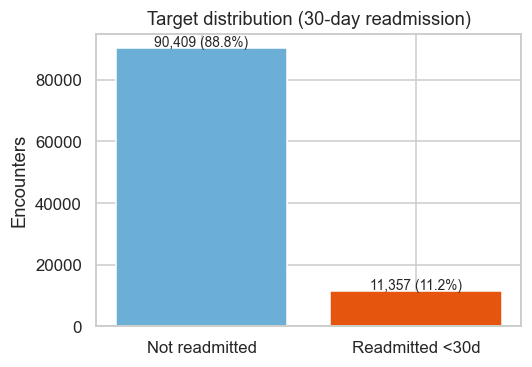

Imbalanced: 11.16% positive — accuracy alone will mislead.


In [4]:
# Target distribution — matplotlib (static) + printed rates
counts = df["readmitted_30_days"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["Not readmitted", "Readmitted <30d"], counts.values, color=["#6baed6", "#e6550d"])
ax.set_title("Target distribution (30-day readmission)")
ax.set_ylabel("Encounters")
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v:,} ({100*v/counts.sum():.1f}%)", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print("Imbalanced:", f"{100*counts[1]/counts.sum():.2f}% positive — accuracy alone will mislead.")

**Interpretation:** ~11% readmitted within 30 days. Imbalanced target — we must report precision/recall/F1/ROC-AUC, not just accuracy.

## 2. Univariate analysis

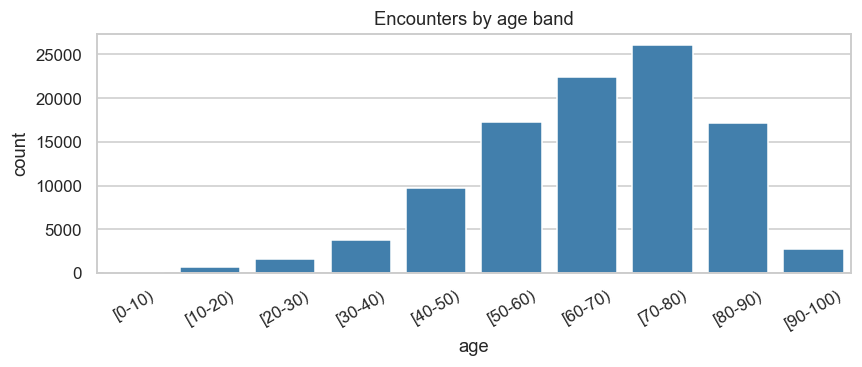

In [5]:
# Age distribution — seaborn
order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
         "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.countplot(data=df, x="age", order=order, ax=ax, color="#3182bd")
ax.set_title("Encounters by age band")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Interpretation:** encounters concentrate in ages 50–90 (diabetes inpatient population). Pediatric bands are tiny — rates computed on them will be noisy.

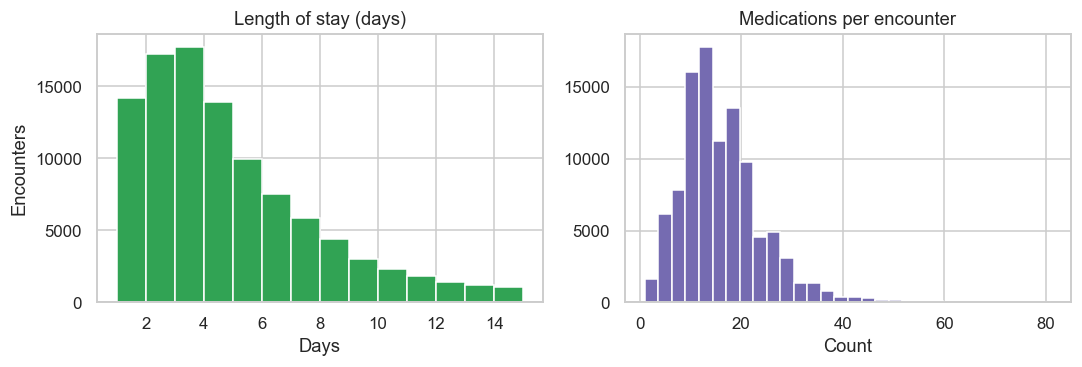

Stay: median 4.0 | Meds: median 15.0


In [6]:
# Length of stay + medication burden — matplotlib
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df["time_in_hospital"], bins=range(1, 16), color="#31a354", edgecolor="white")
axes[0].set_title("Length of stay (days)")
axes[0].set_xlabel("Days"); axes[0].set_ylabel("Encounters")
axes[1].hist(df["num_medications"], bins=30, color="#756bb1", edgecolor="white")
axes[1].set_title("Medications per encounter")
axes[1].set_xlabel("Count")
plt.tight_layout(); plt.show()
print("Stay: median", df.time_in_hospital.median(), "| Meds: median", df.num_medications.median())

**Interpretation:** stays are short (median 4 days, capped at 14 by study design). Medication counts skew right — a long tail of complex polypharmacy cases.

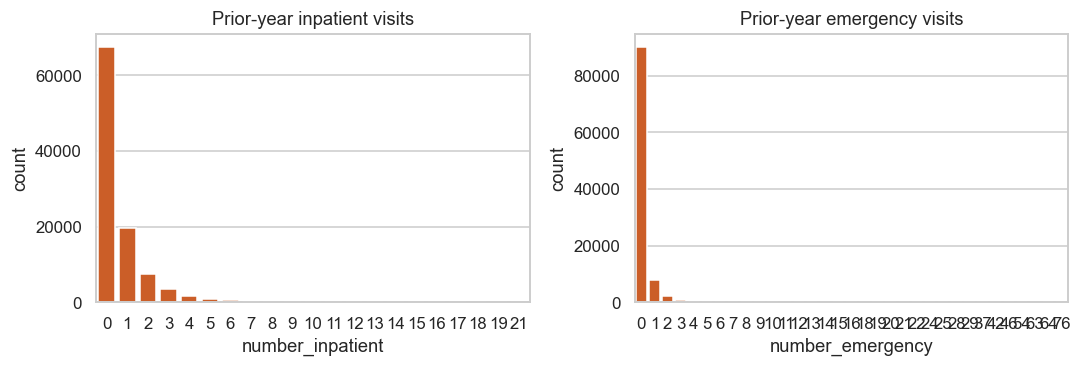

Share with any prior inpatient: 33.5 %


In [7]:
# Prior-year utilization — seaborn
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.countplot(data=df, x="number_inpatient", ax=axes[0], color="#e6550d")
axes[0].set_title("Prior-year inpatient visits")
sns.countplot(data=df, x="number_emergency", ax=axes[1], color="#e6550d")
axes[1].set_title("Prior-year emergency visits")
plt.tight_layout(); plt.show()
print("Share with any prior inpatient:", round(100*(df.number_inpatient > 0).mean(), 1), "%")

**Interpretation:** most encounters have zero prior inpatient/ER visits — repeat users are a minority. That minority is exactly the high-risk group (see bivariate).

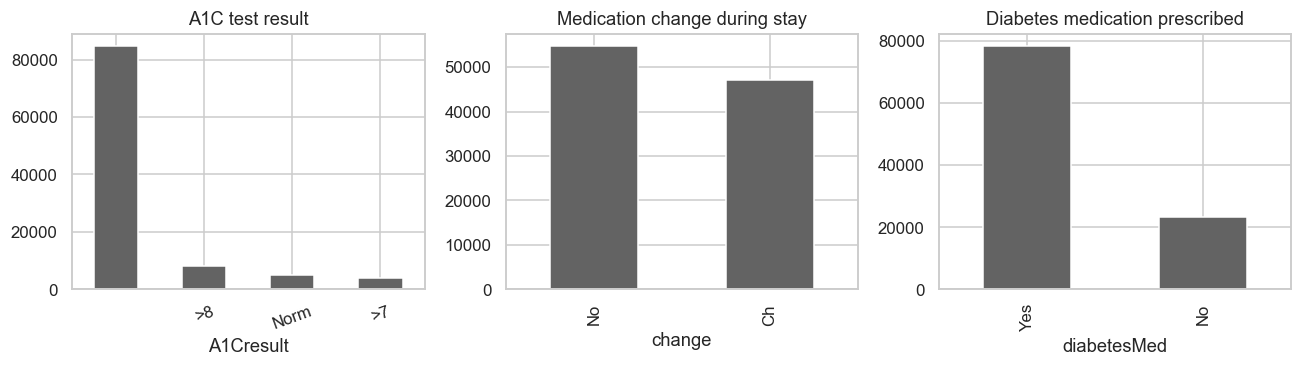

In [8]:
# Diabetes-care variables — matplotlib
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
df["A1Cresult"].value_counts().plot.bar(ax=axes[0], color="#636363")
axes[0].set_title("A1C test result"); axes[0].tick_params(axis="x", rotation=20)
df["change"].value_counts().plot.bar(ax=axes[1], color="#636363")
axes[1].set_title("Medication change during stay")
df["diabetesMed"].value_counts().plot.bar(ax=axes[2], color="#636363")
axes[2].set_title("Diabetes medication prescribed")
plt.tight_layout(); plt.show()

**Interpretation:** A1C was not measured in most stays (`None` = test not done) — testing itself is a care signal worth analyzing. Medication was changed in ~half the stays.

## 3. Bivariate analysis (vs 30-day readmission)

In [9]:
# Readmission rate by age — plotly (interactive business chart)
g = df.groupby("age")["readmitted_30_days"].agg(["mean", "count"]).reset_index()
g["rate_pct"] = (100*g["mean"]).round(2)
fig = px.bar(g, x="age", y="rate_pct", text="rate_pct", color="rate_pct",
             color_continuous_scale="Reds", title="30-day readmission rate by age band (%)")
fig.update_layout(xaxis_title="Age band", yaxis_title="Readmission %")
fig.show()
print(g.sort_values("rate_pct", ascending=False).head(3).to_string(index=False))

    age     mean  count  rate_pct
[20-30) 0.142426   1657     14.24
[80-90) 0.120835  17197     12.08
[70-80) 0.117731  26068     11.77


**Interpretation:** [20-30) leads on rate but is small; among large cohorts the 70–90 bands are highest. Pediatric bands are too small to trust.

In [10]:
# Admission type + discharge group — plotly
adm_map = {1: "Emergency", 2: "Urgent", 3: "Elective", 4: "Newborn",
           5: "Not Available", 6: "NULL", 7: "Trauma", 8: "Not Mapped"}
a = df.groupby("admission_type_id")["readmitted_30_days"].mean().mul(100).round(2).reset_index()
a["type"] = a["admission_type_id"].map(adm_map)
fig = px.bar(a.sort_values("readmitted_30_days"), x="readmitted_30_days", y="type",
             orientation="h", text="readmitted_30_days", color="readmitted_30_days",
             color_continuous_scale="Blues", title="Readmission rate by admission type (%)")
fig.show()

d = df.groupby("length_of_stay_band", observed=True)["readmitted_30_days"].mean().mul(100).round(2)
fig2 = px.bar(d, text=d.values, color=d.values, color_continuous_scale="Greens",
              title="Readmission rate by length-of-stay band (%)")
fig2.update_layout(xaxis_title="Stay band", yaxis_title="Readmission %", showlegend=False)
fig2.show()

**Interpretation:** emergency admissions return more than elective ones (operational difference worth reviewing). Longer stays monotonically align with higher return rates.

C:\Users\ACER\AppData\Local\Temp\ipykernel_16996\107583711.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Not readmitted", "Readmitted"])


C:\Users\ACER\AppData\Local\Temp\ipykernel_16996\107583711.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not readmitted", "Readmitted"])


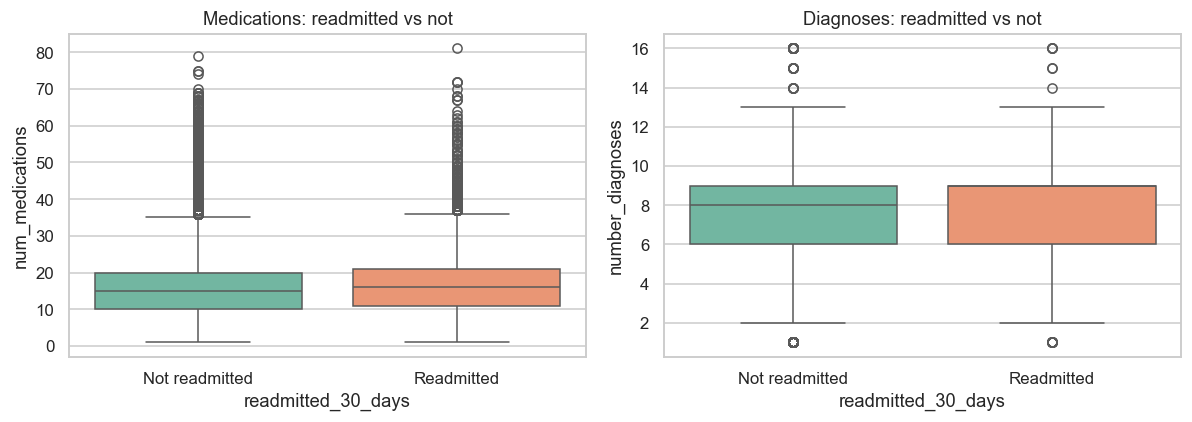

In [11]:
# Clinical load vs outcome — seaborn boxplots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x="readmitted_30_days", y="num_medications", ax=axes[0],
            hue="readmitted_30_days", palette="Set2", legend=False)
axes[0].set_title("Medications: readmitted vs not")
axes[0].set_xticklabels(["Not readmitted", "Readmitted"])
sns.boxplot(data=df, x="readmitted_30_days", y="number_diagnoses", ax=axes[1],
            hue="readmitted_30_days", palette="Set2", legend=False)
axes[1].set_title("Diagnoses: readmitted vs not")
axes[1].set_xticklabels(["Not readmitted", "Readmitted"])
plt.tight_layout(); plt.show()

**Interpretation:** readmitted encounters carry slightly more medications and diagnoses — complexity signals, not proof of cause.

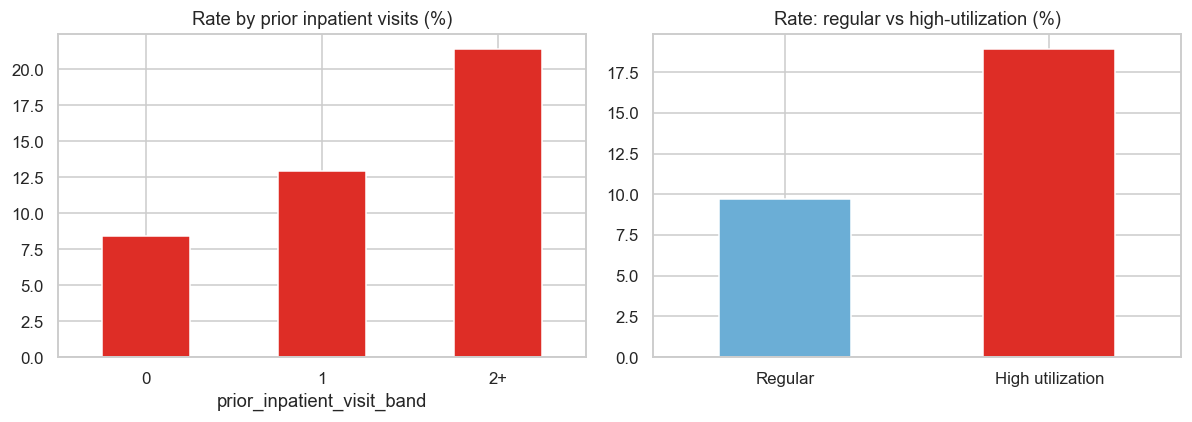

prior_inpatient_visit_band
0      8.44
1     12.92
2+    21.40 
 Regular              9.72
High utilization    18.93


In [12]:
# Prior utilization vs readmission — matplotlib grouped bars
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
p1 = df.groupby("prior_inpatient_visit_band", observed=True)["readmitted_30_days"].mean().mul(100)
p1.plot.bar(ax=axes[0], color="#de2d26")
axes[0].set_title("Rate by prior inpatient visits (%)")
axes[0].tick_params(axis="x", rotation=0)
p2 = df.groupby("high_utilization_flag")["readmitted_30_days"].mean().mul(100)
p2.index = ["Regular", "High utilization"]
p2.plot.bar(ax=axes[1], color=["#6baed6", "#de2d26"])
axes[1].set_title("Rate: regular vs high-utilization (%)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
print(p1.round(2).to_string(), "\n", p2.round(2).to_string())

**Interpretation:** strongest pattern in the data — 2+ prior inpatient stays → ~21% return rate vs ~8% with none. High-utilization flag nearly doubles the rate. Past use predicts future use.

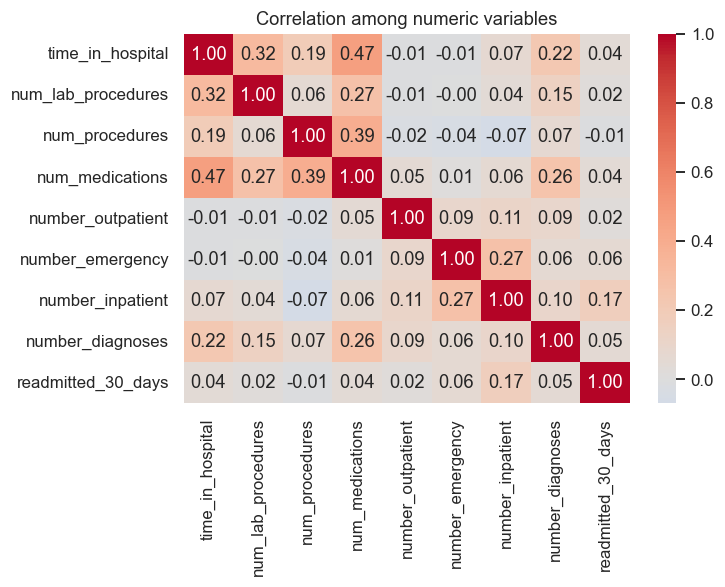

In [13]:
# Numeric correlations — seaborn heatmap
num = df[["time_in_hospital", "num_lab_procedures", "num_procedures",
            "num_medications", "number_outpatient", "number_emergency",
            "number_inpatient", "number_diagnoses", "readmitted_30_days"]]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(num.corr().round(2), annot=True, cmap="coolwarm", center=0, ax=ax, fmt=".2f")
ax.set_title("Correlation among numeric variables")
plt.tight_layout(); plt.show()

**Interpretation:** no single numeric dominates (all |r| with target < 0.2) — readmission is multi-factor, which is why we model it. Prior inpatient/ER visits correlate most with the target.

## Key EDA takeaways

1. Target is imbalanced (11.2% positive) — judge models on recall/F1/ROC-AUC.
2. Prior inpatient/ER use is the strongest return signal (2+ prior stays → ~21%).
3. Older bands (70–90) combine high rates with huge volume — biggest workload impact.
4. Emergency admissions and long stays return more than elective/short stays.
5. Heavier diagnosis/medication loads align with higher return rates.
6. A1C testing is rare — measurement itself is a care-process signal.